# Geospatial Airbnb Hotspot Detection with DBSCAN

## Objective

The objective of this notebook is to identify geographic concentrations of
Airbnb listings in New York City without specifying the number of clusters
in advance.

DBSCAN is used to:

- discover dense geographic listing hotspots;
- separate dense areas from spatially isolated listings;
- compare hotspot characteristics such as price and availability;
- examine how sensitive the results are to the DBSCAN distance parameter.

## Machine-learning task

This is an unsupervised geospatial clustering problem.

The model receives only the latitude and longitude of each listing. Variables
such as price, room type and borough are not used to form the clusters.
Instead, they are used afterwards to interpret and profile the discovered
hotspots.

In [2]:
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
EARTH_RADIUS_KM = 6371.0088

c:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.4.0) or chardet (7.4.3)/charset_normalizer (3.4.2) doesn't match a supported version!
  warnings.warn(


In [3]:
dataset_path = Path(
    kagglehub.dataset_download(
        "dgomonov/new-york-city-airbnb-open-data"
    )
)

csv_files = list(
    dataset_path.rglob("AB_NYC_2019.csv")
)

if not csv_files:
    raise FileNotFoundError(
        f"AB_NYC_2019.csv was not found inside {dataset_path}"
    )

data_path = csv_files[0]

raw_airbnb_df = pd.read_csv(data_path)

print(f"Dataset path: {data_path}")
print(f"Dataset shape: {raw_airbnb_df.shape}")

raw_airbnb_df.head()

100%|██████████| 2.44M/2.44M [00:01<00:00, 2.51MB/s]

Extracting files...


Dataset path: C:\Users\ADMIN\.cache\kagglehub\datasets\dgomonov\new-york-city-airbnb-open-data\versions\3\AB_NYC_2019.csv
Dataset shape: (48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [4]:
raw_airbnb_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [5]:
raw_airbnb_df.describe(
    include="all"
).T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,48895.0,NaN,NaN,NaN,19017143.23618,10983108.38561,2539.0,9471945.0,19677284.0,29152178.5,36487245.0
name,48879,47905,Hillside Hotel,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_id,48895.0,NaN,NaN,NaN,67620010.64661,78610967.032667,2438.0,7822033.0,30793816.0,107434423.0,274321313.0
host_name,48874,11452,Michael,417,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood_group,48895,5,Manhattan,21661,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood,48895,221,Williamsburg,3920,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,48895.0,NaN,NaN,NaN,40.728949,0.05453,40.49979,40.6901,40.72307,40.763115,40.91306
longitude,48895.0,NaN,NaN,NaN,-73.95217,0.046157,-74.24442,-73.98307,-73.95568,-73.936275,-73.71299
room_type,48895,3,Entire home/apt,25409,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,48895.0,NaN,NaN,NaN,152.720687,240.15417,0.0,69.0,106.0,175.0,10000.0


### Initial dataset observations

The dataset contains 48,895 Airbnb listings and 16 variables. Each row
represents one listing advertised in New York City during 2019.

The available variables include:

- identifiers for listings and hosts;
- borough and neighbourhood names;
- latitude and longitude;
- room type and nightly price;
- minimum-night requirements;
- review activity;
- host listing counts;
- yearly availability.

Missing values occur in `name`, `host_name`, `last_review` and
`reviews_per_month`. Both review-related columns contain 10,052 missing
values, which likely represent listings without recorded reviews.

Several variables contain extreme values. Prices range from $0 to $10,000,
minimum stays range from 1 to 1,250 nights, and some hosts manage as many as
327 listings. These extremes show that the numerical distributions are
strongly skewed and that median values will generally be more reliable than
means for cluster profiling.

In [6]:
selected_columns = [
    "id",
    "host_id",
    "neighbourhood_group",
    "neighbourhood",
    "latitude",
    "longitude",
    "room_type",
    "price",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365"
]

airbnb_df = raw_airbnb_df[
    selected_columns
].copy()

In [ ]:
numeric_columns = [
    "latitude",
    "longitude",
    "price",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365"
]

for column in numeric_columns:
    airbnb_df[column] = pd.to_numeric(
        airbnb_df[column],
        errors="coerce"
    )

airbnb_df["reviews_per_month"] = (
    airbnb_df["reviews_per_month"]
    .fillna(0)
)

rows_before_cleaning = len(airbnb_df)

airbnb_df = (
    airbnb_df
    .dropna(
        subset=[
            "latitude",
            "longitude",
            "price",
            "neighbourhood_group",
            "neighbourhood"
        ]
    )
    .query(
        "40.4 <= latitude <= 41.0"
        " and -74.3 <= longitude <= -73.6"
        " and price > 0"
    )
    .reset_index(drop=True)
)

rows_removed = (
    rows_before_cleaning
    - len(airbnb_df)
)

print(f"Rows before cleaning: {rows_before_cleaning:,}")
print(f"Rows after cleaning:  {len(airbnb_df):,}")
print(f"Rows removed:         {rows_removed:,}")
print(
    "Duplicate listing IDs:",
    airbnb_df["id"].duplicated().sum()
)

Rows before cleaning: 48,895
Rows after cleaning:  48,884
Rows removed:         11
Duplicate listing IDs: 0


### Data cleaning findings

Cleaning reduced the dataset from 48,895 to 48,884 observations, meaning only
11 listings were removed. These observations failed the coordinate and price
validity requirements, primarily because their recorded price was zero.

No duplicate listing IDs remained.

Missing `reviews_per_month` values were replaced with zero because these
listings had no recorded review activity. Other variables not required for
the analysis, such as listing and host names, were excluded.

Repeated coordinates were retained because multiple legitimate Airbnb
listings can exist within the same apartment building. Removing them would
artificially reduce the measured listing density, which is the main signal
used by DBSCAN.

The remaining 48,884 observations provided a sufficiently large dataset for
density-based geospatial clustering.

In [8]:
borough_summary_df = (
    airbnb_df
    .groupby(
        "neighbourhood_group",
        observed=True
    )
    .agg(
        listings=("id", "size"),
        neighbourhoods=(
            "neighbourhood",
            "nunique"
        ),
        median_price=(
            "price",
            "median"
        ),
        median_availability=(
            "availability_365",
            "median"
        )
    )
    .sort_values(
        "listings",
        ascending=False
    )
    .reset_index()
)

borough_summary_df

,neighbourhood_group,listings,neighbourhoods,median_price,median_availability
0,Manhattan,21660,32,150.0,36.0
1,Brooklyn,20095,47,90.0,28.0
2,Queens,5666,51,75.0,98.0
3,Bronx,1090,48,65.0,148.0
4,Staten Island,373,43,75.0,219.0


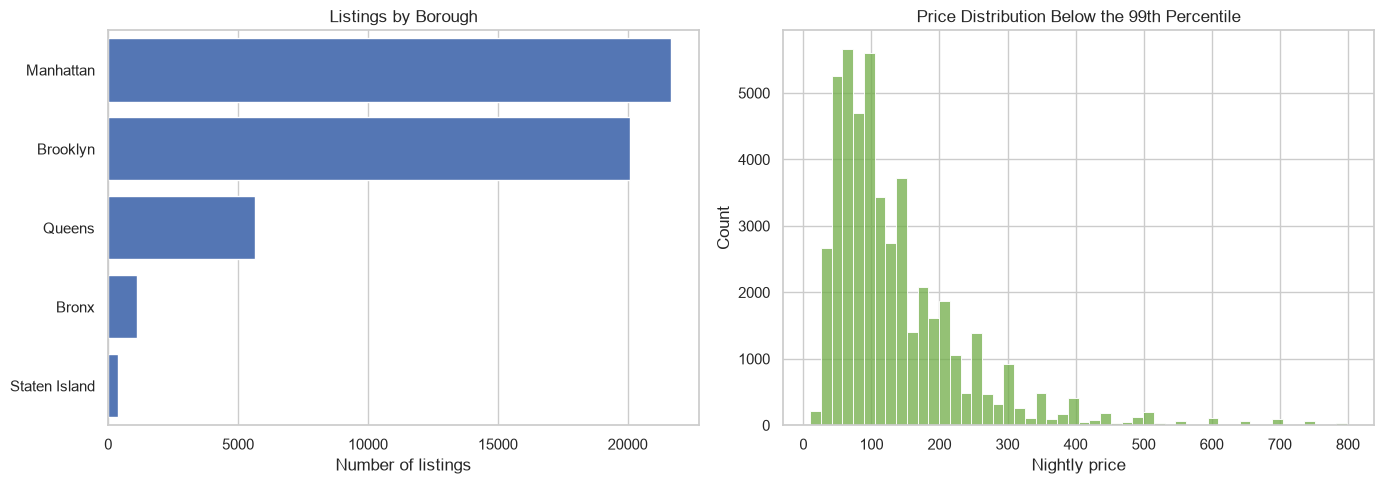

In [9]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

sns.countplot(
    data=airbnb_df,
    y="neighbourhood_group",
    order=airbnb_df[
        "neighbourhood_group"
    ].value_counts().index,
    color="#4472C4",
    ax=axes[0]
)

axes[0].set_title("Listings by Borough")
axes[0].set_xlabel("Number of listings")
axes[0].set_ylabel("")

price_display_limit = airbnb_df[
    "price"
].quantile(0.99)

sns.histplot(
    data=airbnb_df[
        airbnb_df["price"]
        <= price_display_limit
    ],
    x="price",
    bins=50,
    color="#70AD47",
    ax=axes[1]
)

axes[1].set_title(
    "Price Distribution Below the 99th Percentile"
)
axes[1].set_xlabel("Nightly price")

plt.tight_layout()
plt.show()

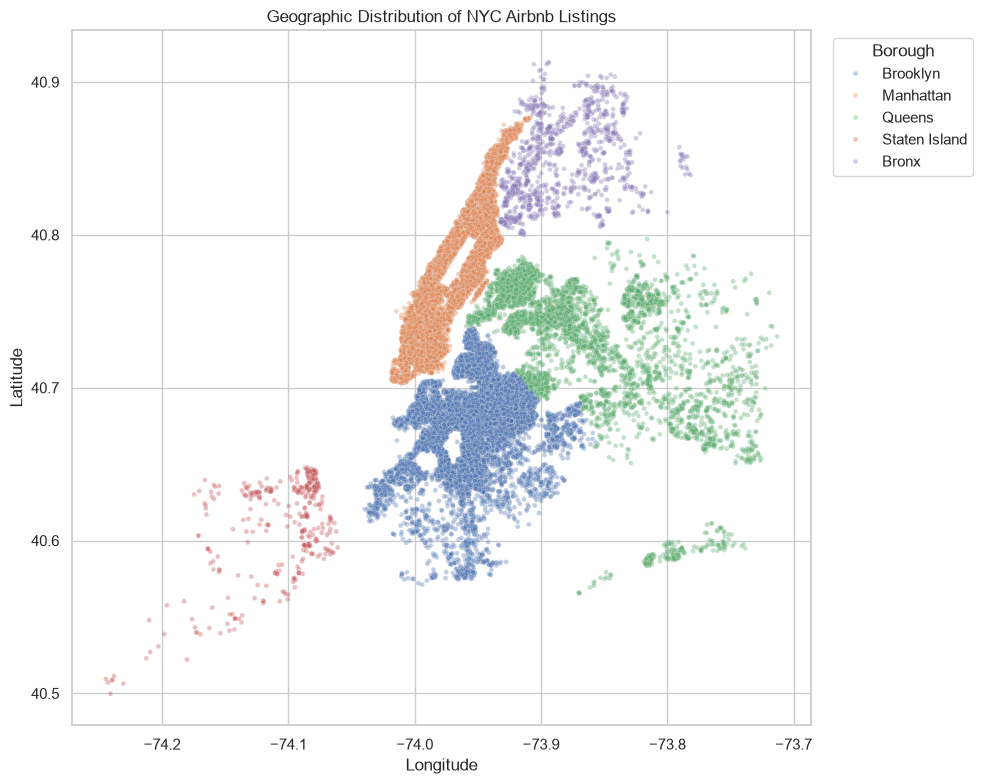

In [10]:
plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=airbnb_df,
    x="longitude",
    y="latitude",
    hue="neighbourhood_group",
    alpha=0.35,
    s=12
)

plt.title("Geographic Distribution of NYC Airbnb Listings")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(
    title="Borough",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### Exploratory results

Manhattan contained the most listings with 21,660, followed closely by
Brooklyn with 20,095. Queens had 5,666 listings, while the Bronx and Staten
Island contained only 1,090 and 373 respectively.

Manhattan had the highest median nightly price at $150. The corresponding
medians were $90 in Brooklyn, $75 in Queens, $65 in the Bronx and $75 in
Staten Island.

Listings in Manhattan and Brooklyn also had much lower median availability,
at 36 and 28 days per year. Median availability increased to 98 days in
Queens, 148 in the Bronx and 219 in Staten Island. Low availability could
reflect greater demand, host behaviour or inactive calendars, so it should
not automatically be interpreted as confirmed bookings.

The price distribution was strongly right-skewed, with a maximum recorded
price of $10,000 compared with a dataset median of $106.

The geographic plot showed very dense and continuous listing concentrations
across Manhattan and northern or central Brooklyn. Queens was more spatially
dispersed, while the Bronx and Staten Island had substantially lower listing
density.

In [11]:
coordinate_columns = [
    "latitude",
    "longitude"
]

coordinates_degrees = airbnb_df[
    coordinate_columns
].to_numpy()

coordinates_radians = np.radians(
    coordinates_degrees
)

print(
    "Coordinate matrix shape:",
    coordinates_radians.shape
)

Coordinate matrix shape: (48884, 2)


In [12]:
MIN_SAMPLES = 20

nearest_neighbour_model = NearestNeighbors(
    n_neighbors=MIN_SAMPLES,
    metric="haversine",
    algorithm="ball_tree",
    n_jobs=-1
)

nearest_neighbour_model.fit(
    coordinates_radians
)

neighbour_distances, _ = (
    nearest_neighbour_model
    .kneighbors(coordinates_radians)
)

kth_neighbour_distances_km = (
    neighbour_distances[:, -1]
    * EARTH_RADIUS_KM
)

pd.Series(
    kth_neighbour_distances_km
).describe(
    percentiles=[
        0.50,
        0.75,
        0.90,
        0.95,
        0.99
    ]
)

count    48884.000000
mean         0.175868
std          0.247501
min          0.024248
50%          0.109588
75%          0.163405
90%          0.340736
95%          0.546597
99%          1.072181
max          8.157729
dtype: float64

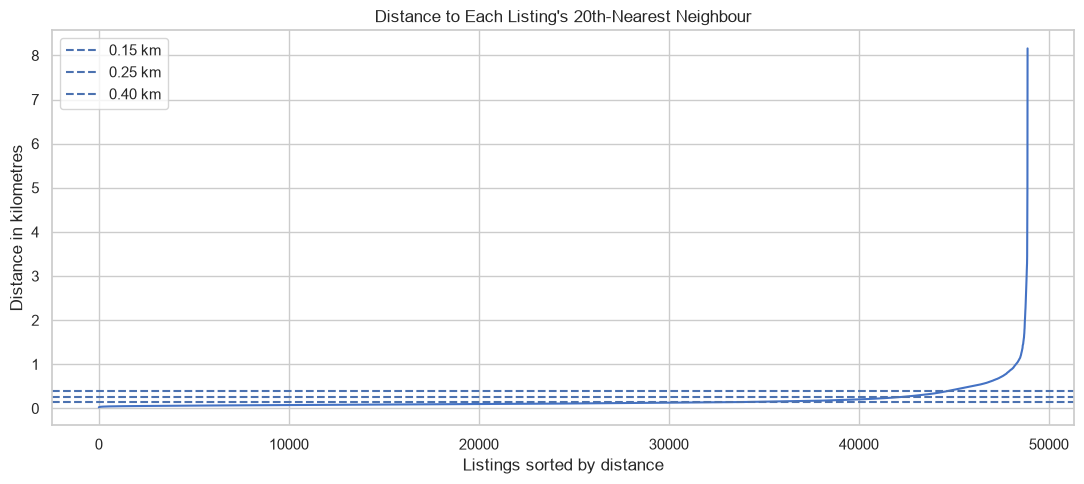

In [13]:
sorted_k_distances = np.sort(
    kth_neighbour_distances_km
)

plt.figure(figsize=(11, 5))

plt.plot(
    sorted_k_distances,
    color="#4472C4"
)

for candidate_eps in [
    0.15,
    0.25,
    0.40
]:
    plt.axhline(
        candidate_eps,
        linestyle="--",
        label=f"{candidate_eps:.2f} km"
    )

plt.title(
    f"Distance to Each Listing's "
    f"{MIN_SAMPLES}th-Nearest Neighbour"
)
plt.xlabel("Listings sorted by distance")
plt.ylabel("Distance in kilometres")
plt.legend()
plt.tight_layout()
plt.show()

### Nearest-neighbour distance findings

The median distance to a listing's 20th-nearest neighbour was approximately
0.110 km, or 110 metres. The corresponding distance percentiles were:

- 75th percentile: 0.163 km
- 90th percentile: 0.341 km
- 95th percentile: 0.547 km
- 99th percentile: 1.072 km

The curve remained relatively flat for most observations before rising
sharply in its upper tail. This indicates that most listings were located in
dense areas, while a smaller group required a much larger search radius to
reach 20 neighbours.

The wide range of distances demonstrates that NYC listing density is not
uniform. Manhattan and central Brooklyn can satisfy DBSCAN's density
requirement within a small radius, while listings in the outer boroughs
require a larger radius. This makes it difficult for one global `eps` value
to represent every borough equally well.

In [14]:
candidate_eps_values_km = [
    0.15,
    0.25,
    0.40
]

sensitivity_rows = []
candidate_labels = {}

for eps_km in candidate_eps_values_km:
    model = DBSCAN(
        eps=eps_km / EARTH_RADIUS_KM,
        min_samples=MIN_SAMPLES,
        metric="haversine",
        algorithm="ball_tree",
        n_jobs=-1
    )

    labels = model.fit_predict(
        coordinates_radians
    )

    candidate_labels[eps_km] = labels

    cluster_labels = labels[
        labels != -1
    ]

    number_of_clusters = len(
        np.unique(cluster_labels)
    )

    noise_percentage = (
        np.mean(labels == -1)
        * 100
    )

    if number_of_clusters > 0:
        cluster_sizes = (
            pd.Series(cluster_labels)
            .value_counts()
        )

        largest_cluster_percentage = (
            cluster_sizes.iloc[0]
            / len(labels)
            * 100
        )
    else:
        largest_cluster_percentage = 0

    sensitivity_rows.append(
        {
            "eps_km": eps_km,
            "clusters": number_of_clusters,
            "noise_percentage": noise_percentage,
            "largest_cluster_percentage":
                largest_cluster_percentage
        }
    )

sensitivity_df = pd.DataFrame(
    sensitivity_rows
)

sensitivity_df

,eps_km,clusters,noise_percentage,largest_cluster_percentage
0,0.15,40,19.783569,41.164798
1,0.25,39,10.635382,44.065543
2,0.40,35,5.821946,90.583831


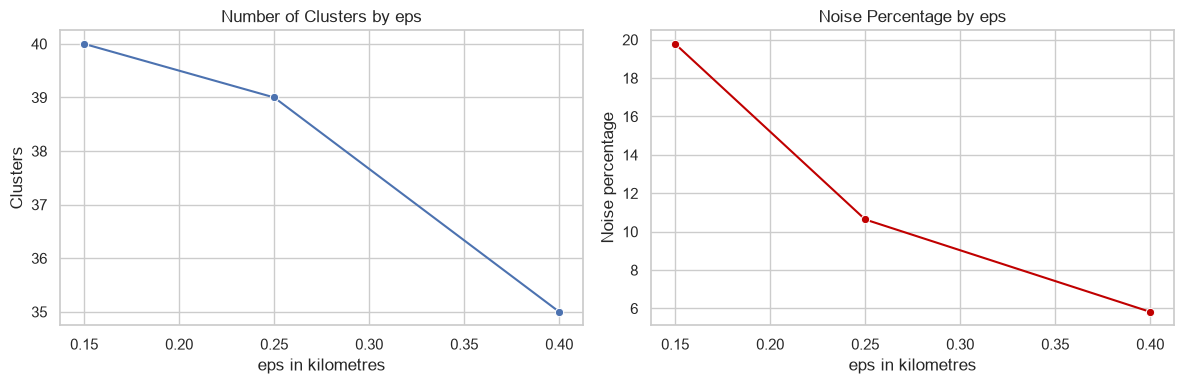

In [15]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4)
)

sns.lineplot(
    data=sensitivity_df,
    x="eps_km",
    y="clusters",
    marker="o",
    ax=axes[0]
)

axes[0].set_title("Number of Clusters by eps")
axes[0].set_xlabel("eps in kilometres")
axes[0].set_ylabel("Clusters")

sns.lineplot(
    data=sensitivity_df,
    x="eps_km",
    y="noise_percentage",
    marker="o",
    color="#C00000",
    ax=axes[1]
)

axes[1].set_title("Noise Percentage by eps")
axes[1].set_xlabel("eps in kilometres")
axes[1].set_ylabel("Noise percentage")

plt.tight_layout()
plt.show()

### Parameter-sensitivity findings

| eps | Clusters | Noise | Largest cluster |
|---:|---:|---:|---:|
| 0.15 km | 40 | 19.78% | 41.16% |
| 0.25 km | 39 | 10.64% | 44.07% |
| 0.40 km | 35 | 5.82% | 90.58% |

Increasing `eps` reduced the percentage of noise because more listings could
connect to nearby core observations. However, it also caused separate dense
regions to merge.

At 0.15 km, almost one-fifth of the listings were classified as noise. Moving
to 0.25 km approximately halved the noise rate while preserving a similar
number of clusters.

At 0.40 km, one cluster absorbed 90.58% of all observations. This is evidence
of DBSCAN's density-connectivity or chaining effect: nearby dense regions
became connected through intermediate observations and were treated as one
continuous cluster.

Therefore, 0.25 km was a reasonable compromise among the tested values. It
reduced excessive noise without collapsing nearly all listings into one
cluster. Nevertheless, its clusters still require further inspection because
the number of clusters alone does not measure their quality.

In [16]:
SELECTED_EPS_KM = 0.25

airbnb_df["cluster"] = candidate_labels[
    SELECTED_EPS_KM
]

non_noise_labels = airbnb_df.loc[
    airbnb_df["cluster"] != -1,
    "cluster"
]

number_of_clusters = (
    non_noise_labels.nunique()
)

noise_count = (
    airbnb_df["cluster"] == -1
).sum()

noise_percentage = (
    noise_count
    / len(airbnb_df)
    * 100
)

cluster_size_df = (
    non_noise_labels
    .value_counts()
    .rename_axis("cluster")
    .reset_index(name="listings")
)

print(f"Selected eps: {SELECTED_EPS_KM:.2f} km")
print(f"Minimum samples: {MIN_SAMPLES}")
print(f"Clusters found: {number_of_clusters}")
print(f"Noise listings: {noise_count:,}")
print(f"Noise percentage: {noise_percentage:.2f}%")

cluster_size_df.head(15)

Selected eps: 0.25 km
Minimum samples: 20
Clusters found: 39
Noise listings: 5,199
Noise percentage: 10.64%


,cluster,listings
0,1,21541
1,0,18448
2,2,1647
3,3,644
4,5,170
5,6,72
6,8,71
7,10,70
8,23,66
9,15,58


### DBSCAN clustering outcome

The selected model used:

- `eps`: 0.25 km
- `min_samples`: 20
- clusters discovered: 39
- noise listings: 5,199
- noise percentage: 10.64%

The four largest clusters contained:

- Cluster 1: 21,541 listings
- Cluster 0: 18,448 listings
- Cluster 2: 1,647 listings
- Cluster 3: 644 listings

Although DBSCAN discovered 39 clusters, the clustering was heavily dominated
by Clusters 1 and 0. Together, these two clusters contained 39,989 listings,
representing approximately 81.8% of the complete dataset and 91.5% of all
non-noise listings.

The outcome therefore contains many small local hotspots but is primarily a
division between two extremely large, continuously dense geographic regions.
Cluster numbers are arbitrary identifiers and do not represent rankings.

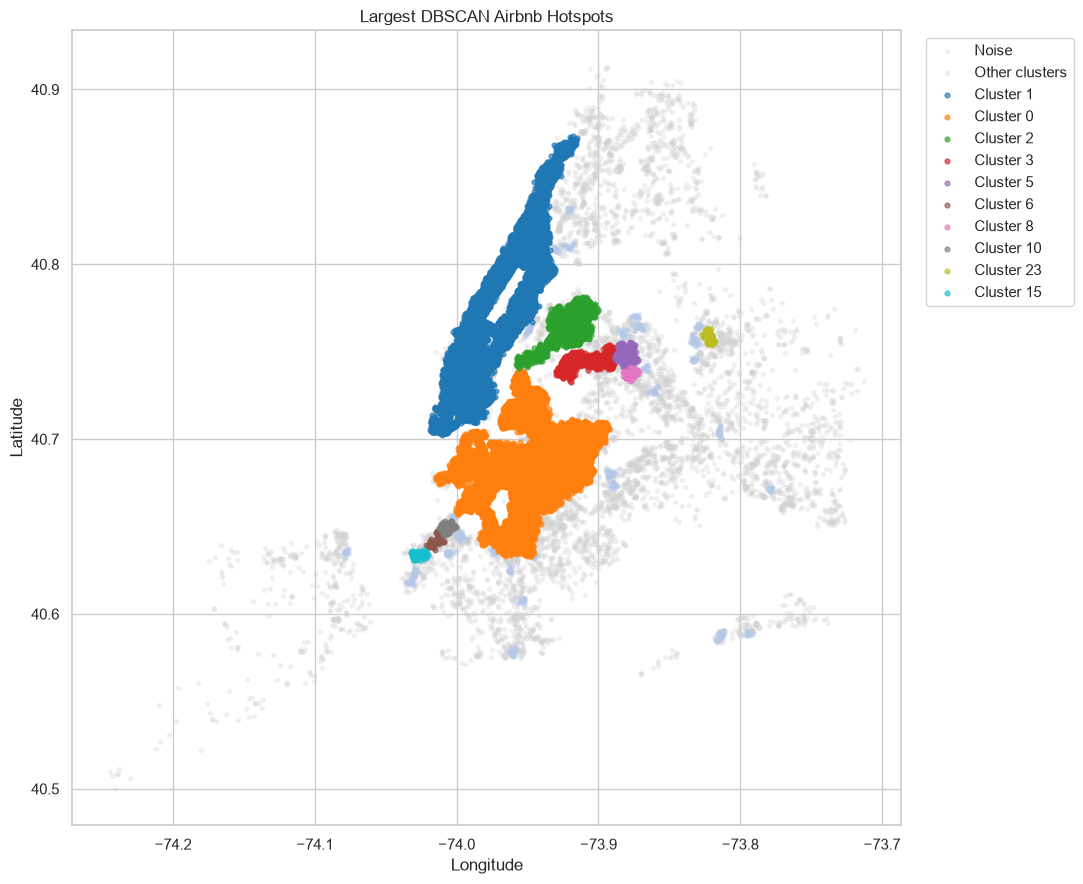

In [17]:
largest_cluster_ids = (
    cluster_size_df
    .head(10)["cluster"]
    .tolist()
)

plt.figure(figsize=(11, 9))

noise_df = airbnb_df[
    airbnb_df["cluster"] == -1
]

plt.scatter(
    noise_df["longitude"],
    noise_df["latitude"],
    color="lightgray",
    alpha=0.25,
    s=8,
    label="Noise"
)

other_cluster_df = airbnb_df[
    (airbnb_df["cluster"] != -1)
    & (
        ~airbnb_df["cluster"]
        .isin(largest_cluster_ids)
    )
]

plt.scatter(
    other_cluster_df["longitude"],
    other_cluster_df["latitude"],
    color="#B4C7E7",
    alpha=0.25,
    s=8,
    label="Other clusters"
)

palette = sns.color_palette(
    "tab10",
    n_colors=len(largest_cluster_ids)
)

for colour, cluster_id in zip(
    palette,
    largest_cluster_ids
):
    cluster_df = airbnb_df[
        airbnb_df["cluster"]
        == cluster_id
    ]

    plt.scatter(
        cluster_df["longitude"],
        cluster_df["latitude"],
        color=colour,
        alpha=0.65,
        s=12,
        label=f"Cluster {cluster_id}"
    )

plt.title("Largest DBSCAN Airbnb Hotspots")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

### Geographic cluster interpretation

Cluster 1 formed a long, continuous region covering most of Manhattan. Its
shape followed Manhattan's geography, demonstrating that DBSCAN can identify
a non-circular spatial cluster.

Cluster 0 covered a large section of Brooklyn and extended across two
boroughs. This shows that DBSCAN forms clusters from spatial connectivity
rather than administrative boundaries.

The next-largest clusters identified denser areas of Queens, including
Astoria and Sunnyside. Additional smaller clusters appeared around Jackson
Heights, Elmhurst, Flushing, southern Brooklyn and Rockaway Beach.

Noise listings were concentrated mainly in the lower-density outer regions
of Queens, the Bronx, Staten Island and peripheral parts of Brooklyn. These
listings did not have at least 20 sufficiently close neighbours under the
selected 0.25 km radius.

The clusters were geographically interpretable, but the two largest clusters
were too broad to represent individual neighbourhood-level hotspots. The
result is more useful for distinguishing large dense Airbnb regions from
peripheral areas than for producing a precise neighbourhood segmentation.

In [18]:
def most_common_value(values):
    modes = values.mode()

    if modes.empty:
        return np.nan

    return modes.iloc[0]

In [19]:
clustered_listings_df = airbnb_df[
    airbnb_df["cluster"] != -1
].copy()

cluster_profile_df = (
    clustered_listings_df
    .groupby(
        "cluster",
        observed=True
    )
    .agg(
        listings=("id", "size"),
        dominant_borough=(
            "neighbourhood_group",
            most_common_value
        ),
        dominant_neighbourhood=(
            "neighbourhood",
            most_common_value
        ),
        boroughs_covered=(
            "neighbourhood_group",
            "nunique"
        ),
        centre_latitude=(
            "latitude",
            "mean"
        ),
        centre_longitude=(
            "longitude",
            "mean"
        ),
        median_price=(
            "price",
            "median"
        ),
        median_minimum_nights=(
            "minimum_nights",
            "median"
        ),
        median_reviews_per_month=(
            "reviews_per_month",
            "median"
        ),
        mean_availability=(
            "availability_365",
            "mean"
        )
    )
    .sort_values(
        "listings",
        ascending=False
    )
    .reset_index()
)

cluster_profile_df.head(15)

,cluster,listings,dominant_borough,dominant_neighbourhood,boroughs_covered,centre_latitude,centre_longitude,median_price,median_minimum_nights,median_reviews_per_month,mean_availability
0,1,21541,Manhattan,Harlem,1,40.765037,-73.974720,150.0,3.0,0.28,112.133234
1,0,18448,Brooklyn,Williamsburg,2,40.691033,-73.949732,95.0,3.0,0.35,93.730811
2,2,1647,Queens,Astoria,1,40.762469,-73.923828,89.0,2.0,0.38,110.338798
3,3,644,Queens,Sunnyside,1,40.743724,-73.911747,70.0,2.0,0.37,128.527950
4,5,170,Queens,Jackson Heights,1,40.748361,-73.880264,59.0,2.0,1.00,145.905882
5,6,72,Brooklyn,Sunset Park,1,40.641890,-74.014916,50.5,2.0,0.62,102.722222
6,8,71,Queens,Elmhurst,1,40.737779,-73.877416,59.0,3.0,0.58,104.774648
7,10,70,Brooklyn,Sunset Park,1,40.649601,-74.006426,77.0,3.0,0.77,105.014286
8,23,66,Queens,Flushing,1,40.758652,-73.821951,85.0,1.0,1.00,196.666667
9,15,58,Brooklyn,Bay Ridge,1,40.633872,-74.026762,75.0,2.0,0.45,154.034483


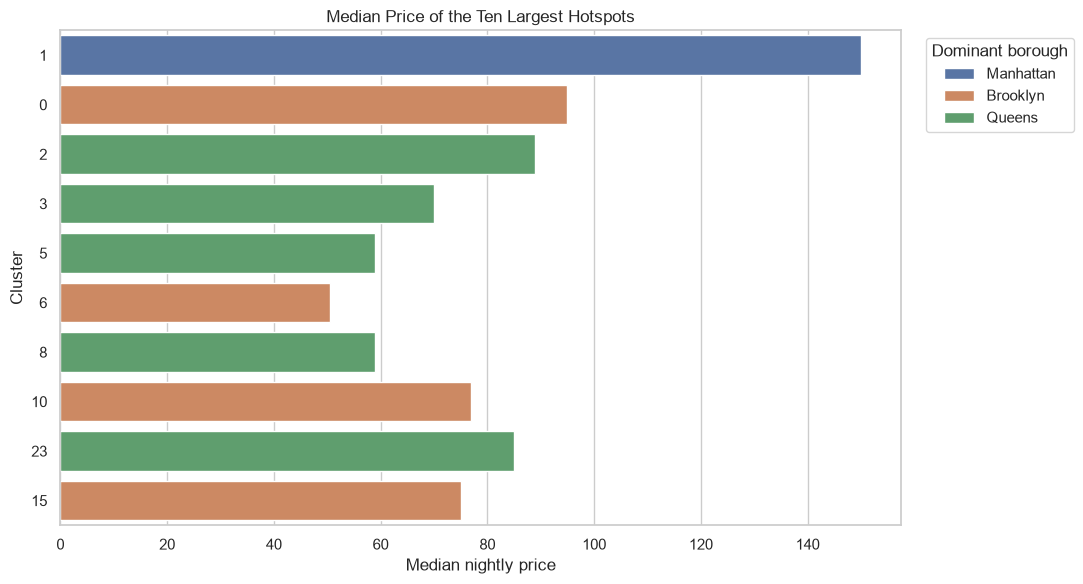

In [20]:
top_cluster_profile_df = (
    cluster_profile_df
    .head(10)
    .copy()
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=top_cluster_profile_df,
    x="median_price",
    y=top_cluster_profile_df[
        "cluster"
    ].astype(str),
    hue="dominant_borough",
    dodge=False
)

plt.title("Median Price of the Ten Largest Hotspots")
plt.xlabel("Median nightly price")
plt.ylabel("Cluster")
plt.legend(
    title="Dominant borough",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

### Hotspot profile findings

The largest cluster contained 21,541 Manhattan listings. Harlem was its most
frequent neighbourhood, but the geographic visualisation showed that the
cluster extended across most of Manhattan. Its median nightly price was
$150, its median minimum stay was three nights and its mean availability was
approximately 112 days.

The second-largest cluster contained 18,448 listings and was dominated by
Brooklyn, particularly Williamsburg. It also crossed into another borough.
Its median price was $95, below Manhattan's $150, while its median minimum
stay was also three nights.

The next two major Queens clusters were:

- Cluster 2: 1,647 listings, dominated by Astoria, with a median price of $89.
- Cluster 3: 644 listings, dominated by Sunnyside, with a median price of $70.

Smaller Queens hotspots included Jackson Heights, Elmhurst and Flushing,
with median prices generally between $59 and $85. Rockaway Beach had a
higher median of $125 despite containing only 47 clustered listings.

The dominant neighbourhood field represents the most frequent neighbourhood
inside a cluster. It should not be interpreted as meaning that the complete
cluster is restricted to that neighbourhood.

Because price, availability and review activity were not used by DBSCAN,
these differences describe the discovered geographic hotspots rather than
factors that directly produced the clusters.

In [21]:
airbnb_df["density_group"] = np.where(
    airbnb_df["cluster"] == -1,
    "Spatial noise",
    "DBSCAN hotspot"
)

density_comparison_df = (
    airbnb_df
    .groupby(
        "density_group",
        observed=True
    )
    .agg(
        listings=("id", "size"),
        median_price=("price", "median"),
        median_minimum_nights=(
            "minimum_nights",
            "median"
        ),
        median_reviews_per_month=(
            "reviews_per_month",
            "median"
        ),
        median_availability=(
            "availability_365",
            "median"
        )
    )
    .reset_index()
)

density_comparison_df

,density_group,listings,median_price,median_minimum_nights,median_reviews_per_month,median_availability
0,DBSCAN hotspot,43685,115.0,3.0,0.33,32.0
1,Spatial noise,5199,70.0,2.0,1.00,157.0


### Hotspot versus noise comparison

| Density group | Listings | Median price | Median minimum nights | Median reviews/month | Median availability |
|---|---:|---:|---:|---:|---:|
| DBSCAN hotspot | 43,685 | $115 | 3 | 0.33 | 32 |
| Spatial noise | 5,199 | $70 | 2 | 1.00 | 157 |

Listings within DBSCAN hotspots had a substantially higher median price:
$115 compared with $70 for spatial noise listings. Hotspot listings also
required a slightly longer median minimum stay of three nights rather than
two.

Hotspot listings had lower median recorded review activity, at 0.33 reviews
per month compared with 1.00 for noise listings. They also had much lower
median availability, with 32 available days compared with 157.

These relationships are descriptive rather than causal. For example, lower
availability may indicate stronger demand, deliberate host restrictions or
an inactive calendar. Similarly, a noise label does not mean that a listing
is unusual in price or quality; it only indicates insufficient local listing
density under the selected DBSCAN parameters.

In [22]:
non_noise_mask = (
    airbnb_df["cluster"].to_numpy()
    != -1
)

non_noise_coordinates = coordinates_radians[
    non_noise_mask
]

non_noise_cluster_labels = airbnb_df.loc[
    non_noise_mask,
    "cluster"
].to_numpy()

rng = np.random.default_rng(
    RANDOM_STATE
)

sample_size = min(
    2000,
    len(non_noise_coordinates)
)

sample_indices = rng.choice(
    len(non_noise_coordinates),
    size=sample_size,
    replace=False
)

sample_coordinates = non_noise_coordinates[
    sample_indices
]

sample_labels = non_noise_cluster_labels[
    sample_indices
]

if len(np.unique(sample_labels)) >= 2:
    sampled_silhouette = silhouette_score(
        sample_coordinates,
        sample_labels,
        metric="haversine"
    )

    print(
        "Sampled non-noise silhouette score:",
        f"{sampled_silhouette:.3f}"
    )
else:
    sampled_silhouette = np.nan

    print(
        "Silhouette score could not be calculated "
        "because the sample contained fewer than "
        "two clusters."
    )

Sampled non-noise silhouette score: -0.045


### Clustering evaluation

The sampled non-noise silhouette score was -0.045. A value slightly below
zero indicates weak global separation: some sampled listings were, on
average, closer to observations in another cluster than to observations
assigned to their own cluster.

This result is consistent with the visual analysis. The Manhattan and
Brooklyn regions formed very large connected shapes, while several smaller
clusters were located close to those dominant regions.

However, silhouette score assumes that compact and clearly separated
clusters are desirable. DBSCAN is designed to discover irregular shapes and
noise, so silhouette score should not be treated as the only measure of
quality.

Other evaluation evidence included:

- a manageable noise rate of 10.64%;
- geographically recognisable dense regions;
- interpretable smaller hotspots in Queens and southern Brooklyn;
- strong sensitivity to the selected `eps`;
- two clusters containing 91.5% of all clustered observations.

Overall, the model was useful for identifying broad high-density Airbnb
regions and spatially isolated listings. It was less successful as a
fine-grained neighbourhood clustering method.